## Comparison of different FDEM forward operators:
* the pyGIMLi built-in EM1dModelling using the quasi-static approximation (Ward & Hohmann, 1989)
* the Python-implementation for HEM taking dielectric displacement into account (Siemon, 2012)
* the very general empymod implementation by Werthmüller et al. (2017)

In [10]:
import numpy as np
import pygimli as pg
from pygimli.physics.em.fdem import HEMmodelling
import empymod

Both pyGIMLi-based forward operators yield the ratio of secondary to primary field, which is defined by (Ward & Hohmann, 1989)
$$ H_z = \frac{1}{4\pi\sqrt{z^2+c^2}^3} \left(\frac{3z^2}{z^2+c^2}-1 \right) $$
where c is the coil spacing and r the distance Tx-Rx. It reduces for $z=0$ to
$$ H_z = -\frac{1}{4\pi c^3} $$

Note that EM1dModelling was designed for ground EM and yields Hs/Hp in percent, whereas HEMModelling was designed for the HEM system that measures Hs/Hp in ppm.

We consider a frequency sounding using a classical HCP (vertical magnetic dipole transmitter and receiver at the same level) configuration.

In [11]:
coilspacing = 100.  # typical distance
freq = 2**np.arange(10) * 110.  # MaxMin/Promys system
height = 1  # both loops carried by a human
fak = 100.  # results as % of primary field

In [ ]:
# Alternatively, we can use a typical airborne case like the RESOLVE bird:
if 1:
    coilspacing = 10.  # RESOLVE bird dimension
    freq = np.array([387., 1820., 8330., 41500., 133400.])
    fak = 1e6  # typically in ppm
    height = 50.  # typical flight elevation

Model is a three-layer model as in pyGIMLi (d1, d2, rho1, rho2, rho3) that can be formulated without (default) or with air.

In [23]:
def addAir(model, height, resAir=1e14):
    """Generate model including air."""
    nlay = (len(model)+1) // 2
    return np.concatenate(([height], model[:nlay-1], [resAir], model[nlay-1:]))

model = [20, 20, 200, 1000, 30]
nlay = (len(model)+1) // 2
modelAir = addAir(model, height)
print(modelAir)

[5.e+01 2.e+01 2.e+01 1.e+14 2.e+02 1.e+03 3.e+01]


In [24]:
fop1 = pg.core.FDEM1dModelling(nlay, freq, coilspacing, height)
fas = (coilspacing**-3)/4/np.pi
fafak = fop1.freeAirSolution()[0] / fas  # bug in freeAir (pgcore<1.4)
resp1 = fop1(model) / 100 * fak * fafak  # returns %, remove fafak reveals bug for heights>>coilspacing
fop1b = pg.core.FDEM1dModelling(nlay+1, freq, coilspacing, 0.0)
resp1b = fop1b(modelAir) / 100 * fak  # returns %
fop2 = HEMmodelling(nlay, height, f=freq, r=coilspacing)
resp2 = fop2(model) / 1e6 * fak  # returns ppm
fop2b = HEMmodelling(nlay+1, 0.1, f=freq, r=coilspacing)
resp2b = fop2b(modelAir) / 1e6 * fak  # returns ppm

In [25]:
def showSounding(f, resp, ax=None, **kwargs):
    """Show FDEM sounding."""
    if ax is None:
        fig, ax = pg.plt.subplots(ncols=2, sharey=True)

    ip, op = np.split(resp, 2)
    ax[0].semilogy(ip, f, **kwargs)
    ax[1].semilogy(op, f, **kwargs)
    ax[0].set_ylim(min(f), max(f))
    ax[0].grid(True)
    ax[1].grid(True)
    return ax

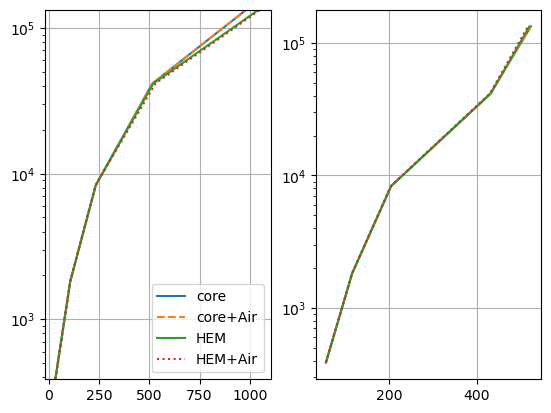

In [27]:
fig, ax = pg.plt.subplots(ncols=2)
showSounding(freq, resp1, ax=ax, label="core")
showSounding(freq, resp1b, ax=ax, label="core+Air", ls="--")
showSounding(freq, resp2, ax=ax, label="HEM")
showSounding(freq, resp2b, ax=ax, label="HEM+Air", ls=":")
ax[0].legend();

In [28]:
print(np.column_stack([resp1, resp1b, resp2, resp2b]))

[[  32.47104224   32.47104224   32.47097138   32.42457233]
 [ 106.66407926  106.66407926  106.66314207  106.41014798]
 [ 233.77961916  233.77961916  233.76806143  232.46500388]
 [ 514.88570258  514.8857026   519.8599802   530.53826464]
 [ 982.65705587  982.65705588 1044.06038891 1052.12362851]
 [  54.88063491   54.88063491   54.8806654    54.74505343]
 [ 114.75731655  114.75731655  114.75783124  114.37787655]
 [ 203.9977752   203.99777522  204.00554836  203.15517949]
 [ 430.72480894  430.72480901  431.57192711  429.35376811]
 [ 523.18847929  523.1884795   519.72676596  516.5019709 ]]


We now want to build the operator using empymod.

In [ ]:
class HCPModellingEMP(pg.frameworks.Modelling):
    """Modelling a HCP coil-coil system by empymod."""

    def __init__(self, freq, coilspacing, height=0):
        """Initialize by saving parameters."""
        super().__init__()
        self.coilspacing = coilspacing
        self.freq = freq
        self.height = height
        self.freeAir = (coilspacing**-3)/4/np.pi

    def response(self, model):
        """Forward response for layered block model."""
        nlay = (len(model)+1) // 2
        thk = model[:nlay-1]
        res = model[nlay-1:]
        assert len(res), len(thk)+1
        inp = dict(res=np.concatenate(([2e14], res)),
                   depth=np.concatenate(([0.1], np.cumsum(thk))),
                   freqtime=self.freq,
                   src=[0, 0, -self.height],
                   rec=[self.coilspacing, 0, -self.height],
                   ab=66, squeeze=True, verb=1, xdirect=True,
                   htarg={'pts_per_dec': 0, 'dlf': 'key_51_2012'}
                  )
        print(inp)
        out = empymod.dipole(**inp)
        print(out)
        out /=  self.freeAir
        return np.concatenate([out.real, out.imag])

fop3 = HCPModellingEMP(freq, coilspacing, height=height)
re = fop3.response([10000])  # should be mainly real-valued primary field

{'res': array([2.e+14, 1.e+04]), 'depth': array([0.1]), 'freqtime': array([   387.,   1820.,   8330.,  41500., 133400.]), 'src': [0, 0, -50.0], 'rec': [10.0, 0, -50.0], 'ab': 66, 'squeeze': True, 'verb': 1, 'xdirect': True, 'htarg': {'pts_per_dec': 0, 'dlf': 'key_51_2012'}}
[-1.89370941e-08+2.60429064e-02j -1.80733304e-08+5.53769578e-03j
 -1.63977788e-08+1.20991713e-03j -4.32587951e-09+2.42834746e-04j
  8.68100177e-08+7.54924056e-05j]


In [30]:
def showSounding(f, resp, ax=None, **kwargs):
    """Show FDEM sounding."""
    if ax is None:
        fig, ax = pg.plt.subplots(ncols=2, sharey=True)

    ip, op = np.split(resp, 2)
    ax[0].semilogy(ip, f, **kwargs)
    ax[1].semilogy(op, f, **kwargs)
    ax[0].set_ylim(min(f), max(f))
    ax[0].grid(True)
    ax[1].grid(True)
    return ax

In [31]:
model = [20, 20, 200, 1000, 30]
nlay = (len(model)+1) // 2
resp1 = fop1(model) / 100 * fak * fafak  # returns %, remove fafak reveals bug for heights>>coilspacing
resp2 = fop2(model) / 1e6 * fak  # returns ppm
resp3 = fop3.response(model) * fak
print(np.column_stack([resp1, resp2, resp3]))

{'res': array([2.e+14, 2.e+02, 1.e+03, 3.e+01]), 'depth': array([ 0.1, 20. , 40. ]), 'freqtime': array([   387.,   1820.,   8330.,  41500., 133400.]), 'src': [0, 0, -50.0], 'rec': [10.0, 0, -50.0], 'ab': 66, 'squeeze': True, 'verb': 1, 'xdirect': True, 'htarg': {'pts_per_dec': 0, 'dlf': 'key_51_2012'}}
[-1.42747787e-06+2.60437510e-02j -6.34041172e-07+5.53828480e-03j
 -2.45708312e-07+1.21019733e-03j -9.51400977e-08+2.42956226e-04j
  5.92753792e-08+7.55652233e-05j]
[[ 3.24710422e+01  3.24709714e+01 -1.79382160e+04]
 [ 1.06664079e+02  1.06663142e+02 -7.96759635e+03]
 [ 2.33779619e+02  2.33768061e+02 -3.08766171e+03]
 [ 5.14885703e+02  5.19859980e+02 -1.19556573e+03]
 [ 9.82657056e+02  1.04406039e+03  7.44876383e+02]
 [ 5.48806349e+01  5.48806654e+01  3.27275427e+08]
 [ 1.14757317e+02  1.14757831e+02  6.95961393e+07]
 [ 2.03997775e+02  2.04005548e+02  1.52077882e+07]
 [ 4.30724809e+02  4.31571927e+02  3.05307798e+06]
 [ 5.23188479e+02  5.19726766e+02  9.49580601e+05]]


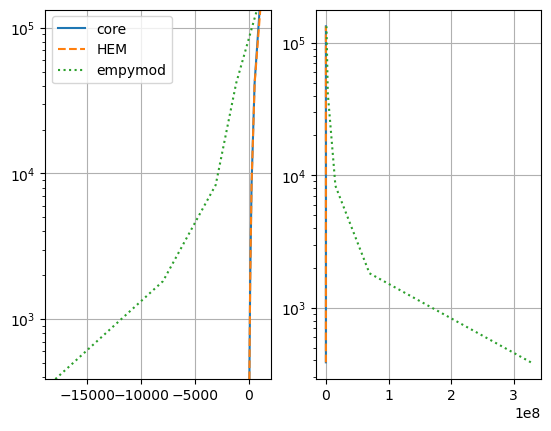

In [32]:
fig, ax = pg.plt.subplots(ncols=2)
showSounding(freq, resp1, ax=ax, label="core")
showSounding(freq, resp2, ax=ax, label="HEM", ls="--")
showSounding(freq, resp3, ax=ax, label="empymod", ls=":");
ax[0].legend();

### References
* Ward, S. H., and G. W. Hohmann, 1987, Electromagnetic theory for geophysical applications, in M. N. Nabighian, ed., Electromagnetic methods in applied geophysics, 1: Theory, SEG, 130–310. 
* Siemon, B. (2012): Accurate 1D forward and inverse modeling of high-frequency helicopter-borne electromagnetic data, Geophysics 77(4), WB71-87.
* Werthmüller, D. (2017): An open-source full 3D electromagnetic modeler for 1D VTI media in Python: empymod, Geophysics 82(6), WB9-19.